In [2]:
import socket, torch
print("GitHub DNS:", socket.gethostbyname("github.com"))
print("GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

GitHub DNS: 140.82.114.3
GPU: True
Tesla T4


In [3]:
!git clone --depth 1 --single-branch --branch ResNet50 https://github.com/mirshadahamed/brain-tumor-mri-classification.git /content/brain-tumor-mri-classification

Cloning into '/content/brain-tumor-mri-classification'...
remote: Enumerating objects: 6720, done.
remote: Counting objects: 100% (6720/6720), done.
remote: Compressing objects: 100% (6713/6713), done.
remote: Total 6720 (delta 5), reused 6719 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (6720/6720), 142.85 MiB | 16.97 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (6700/6700), done.


In [4]:
from pathlib import Path
import torch, torchvision, sklearn, matplotlib, PIL

repo = Path("/content/brain-tumor-mri-classification")
assert (repo / "resnet50/train.py").is_file()

for split, expected in {"train": 4673, "validation": 1003, "test": 1001}.items():
    count = len(list((repo / "Dataset-Split" / split).rglob("*.jpg")))
    print(split, count)
    assert count == expected

print("PyTorch:", torch.__version__, "Torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.get_device_name(0))

train 4673
validation 1003
test 1001
PyTorch: 2.11.0+cu128 Torchvision: 0.26.0+cu128
GPU: Tesla T4


In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
from pathlib import Path
import sys
import torch

repo = Path("/content/brain-tumor-mri-classification")
data_root = repo / "Dataset-Split"
sys.path.insert(0, str(repo / "resnet50"))

from spec import verify_manifest

assert torch.cuda.is_available(), "Select a GPU runtime"
assert data_root.is_dir(), f"Dataset missing: {data_root}"

for split in ("train", "validation"):
    verify_manifest(data_root, split)
    print(f"{split}: files, labels, and SHA-256 hashes verified")

print("GPU:", torch.cuda.get_device_name(0))
print("Test set has not been opened.")

train: files, labels, and SHA-256 hashes verified
validation: files, labels, and SHA-256 hashes verified
GPU: Tesla T4
Test set has not been opened.


Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training images: 4673
Validation images: 1003
Training class counts: {0: 1244, 1: 1039, 2: 1160, 3: 1230}


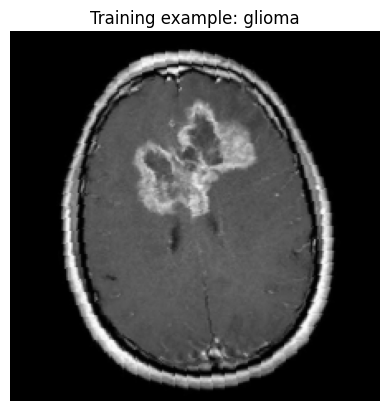

Image tensor shape: (3, 224, 224)


In [7]:
from collections import Counter
from torch.utils.data import DataLoader
from common import (
    CLASS_TO_IDX, WEIGHTS, set_seed,
    image_folder, train_transform, evaluation_transform
)
import matplotlib.pyplot as plt

set_seed(42)

train_data = image_folder(data_root, "train", train_transform())
val_data = image_folder(data_root, "validation", evaluation_transform())

train_loader = DataLoader(
    train_data, batch_size=16, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_data, batch_size=16, shuffle=False,
    num_workers=2, pin_memory=True
)

print("Classes:", CLASS_TO_IDX)
print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Training class counts:", dict(Counter(train_data.targets)))

image, label = train_data[0]
mean = torch.tensor(WEIGHTS.transforms().mean).view(3, 1, 1)
std = torch.tensor(WEIGHTS.transforms().std).view(3, 1, 1)
preview = (image * std + mean).clamp(0, 1).permute(1, 2, 0)

plt.imshow(preview)
plt.title(f"Training example: {train_data.classes[label]}")
plt.axis("off")
plt.show()
print("Image tensor shape:", tuple(image.shape))

In [12]:
import json
from torch import nn
from common import make_model, configure_phase, WEIGHTS

run_dir = Path("/content/drive/MyDrive/SE4050/resnet50-stepwise-02")
assert not run_dir.exists(), "This run folder exists; choose a new name"

run_dir.parent.mkdir(parents=True, exist_ok=True)
torch.hub.set_dir(str(run_dir.parent / "torch-hub"))

device = torch.device("cuda")
model = make_model(pretrained=True).to(device)  # May download ImageNet weights
configure_phase(model, "head")                    # Train final layer only

criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

run_dir.mkdir()
config = {
    "model": "ResNet50",
    "weights": str(WEIGHTS),
    "classes": CLASS_TO_IDX,
    "seed": 42,
    "batch_size": 16,
    "head_epochs": 5,
    "fine_tune_epochs": 10,
    "total_parameters": total_params,
    "head_trainable_parameters": trainable_params,
}
(run_dir / "config.json").write_text(json.dumps(config, indent=2))

print("Final layer:", model.fc)
print("Total parameters:", total_params)
print("Trainable now:", trainable_params)
print("Outputs will be saved to:", run_dir)

Final layer: Linear(in_features=2048, out_features=4, bias=True)
Total parameters: 23516228
Trainable now: 8196
Outputs will be saved to: /content/drive/MyDrive/SE4050/resnet50-stepwise-02


Epoch 1/5 | train loss 0.6256, accuracy 0.7905 | validation loss 0.4853, accuracy 0.8465, macro-F1 0.8388  ← best so far
Epoch 2/5 | train loss 0.3850, accuracy 0.8733 | validation loss 0.4351, accuracy 0.8554, macro-F1 0.8489  ← best so far
Epoch 3/5 | train loss 0.3285, accuracy 0.8894 | validation loss 0.3850, accuracy 0.8794, macro-F1 0.8747  ← best so far
Epoch 4/5 | train loss 0.2928, accuracy 0.9001 | validation loss 0.3730, accuracy 0.8804, macro-F1 0.8772  ← best so far
Epoch 5/5 | train loss 0.2617, accuracy 0.9120 | validation loss 0.3426, accuracy 0.8923, macro-F1 0.8890  ← best so far
Head training complete. Best epoch: 5


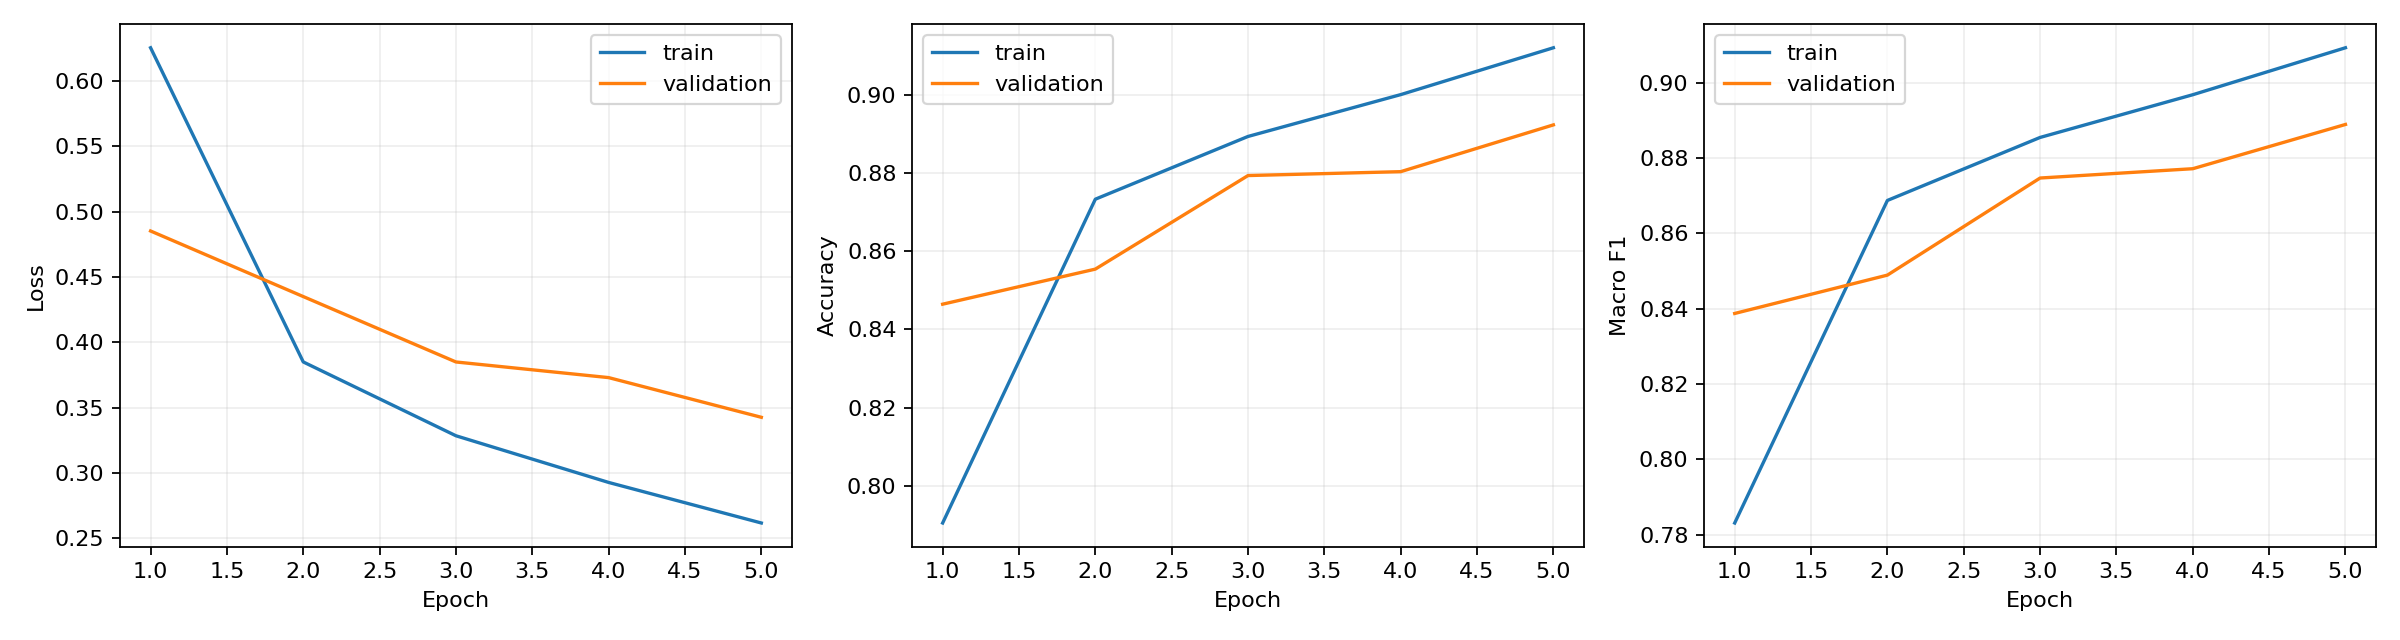

In [13]:
import os
import time
from IPython.display import display, Image as NotebookImage
from train import run_epoch, save_history, save_curves

assert not (run_dir / "history.csv").exists(), (
    "Training has already started in this run folder. Do not rerun this cell."
)

history = []
best_f1 = -1.0
best_loss = float("inf")
best_epoch = None
non_improving = 0

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

for epoch in range(1, 6):
    start = time.perf_counter()

    train_scores = run_epoch(
        model, train_loader, criterion, device,
        optimizer, scaler, "head"
    )
    with torch.inference_mode():
        val_scores = run_epoch(model, val_loader, criterion, device)

    scheduler.step(val_scores["loss"])

    history.append({
        "epoch": epoch,
        "phase": "head",
        **{f"train_{k}": v for k, v in train_scores.items()},
        **{f"val_{k}": v for k, v in val_scores.items()},
        "minutes": round((time.perf_counter() - start) / 60, 3),
        "head_lr": optimizer.param_groups[-1]["lr"],
        "backbone_lr": 0.0,
    })
    save_history(run_dir / "history.csv", history)
    save_curves(run_dir / "learning_curves.png", history)

    improved = (
        val_scores["macro_f1"] > best_f1 + 1e-6
        or (
            abs(val_scores["macro_f1"] - best_f1) <= 1e-6
            and val_scores["loss"] < best_loss
        )
    )

    if improved:
        best_f1 = val_scores["macro_f1"]
        best_loss = val_scores["loss"]
        best_epoch = epoch
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": CLASS_TO_IDX,
            "weights": str(WEIGHTS),
            "epoch": epoch,
            "phase": "head",
            "validation_macro_f1": best_f1,
            "validation_loss": best_loss,
        }
        torch.save(checkpoint, run_dir / "best.tmp.pt")
        os.replace(run_dir / "best.tmp.pt", run_dir / "best.pt")
        non_improving = 0
    else:
        non_improving += 1

    print(
        f"Epoch {epoch}/5 | "
        f"train loss {train_scores['loss']:.4f}, "
        f"accuracy {train_scores['accuracy']:.4f} | "
        f"validation loss {val_scores['loss']:.4f}, "
        f"accuracy {val_scores['accuracy']:.4f}, "
        f"macro-F1 {val_scores['macro_f1']:.4f}"
        + ("  ← best so far" if improved else ""),
        flush=True,
    )

    if non_improving >= 4:
        print("Head training stopped early.")
        break

print(f"Head training complete. Best epoch: {best_epoch}")
display(NotebookImage(filename=str(run_dir / "learning_curves.png")))

Trainable parameters: 14972932
Epoch 6 (fine-tune 1/10) | train loss 0.3216, accuracy 0.8971 | validation loss 0.3400, accuracy 0.8863, macro-F1 0.8822
Epoch 7 (fine-tune 2/10) | train loss 0.2216, accuracy 0.9247 | validation loss 0.2737, accuracy 0.9113, macro-F1 0.9082  ← overall best
Epoch 8 (fine-tune 3/10) | train loss 0.1694, accuracy 0.9403 | validation loss 0.2280, accuracy 0.9292, macro-F1 0.9274  ← overall best
Epoch 9 (fine-tune 4/10) | train loss 0.1350, accuracy 0.9555 | validation loss 0.2118, accuracy 0.9222, macro-F1 0.9194
Epoch 10 (fine-tune 5/10) | train loss 0.1108, accuracy 0.9640 | validation loss 0.1946, accuracy 0.9272, macro-F1 0.9254
Epoch 11 (fine-tune 6/10) | train loss 0.0868, accuracy 0.9711 | validation loss 0.1730, accuracy 0.9422, macro-F1 0.9408  ← overall best
Epoch 12 (fine-tune 7/10) | train loss 0.0732, accuracy 0.9786 | validation loss 0.1787, accuracy 0.9362, macro-F1 0.9347
Epoch 13 (fine-tune 8/10) | train loss 0.0569, accuracy 0.9842 | valida

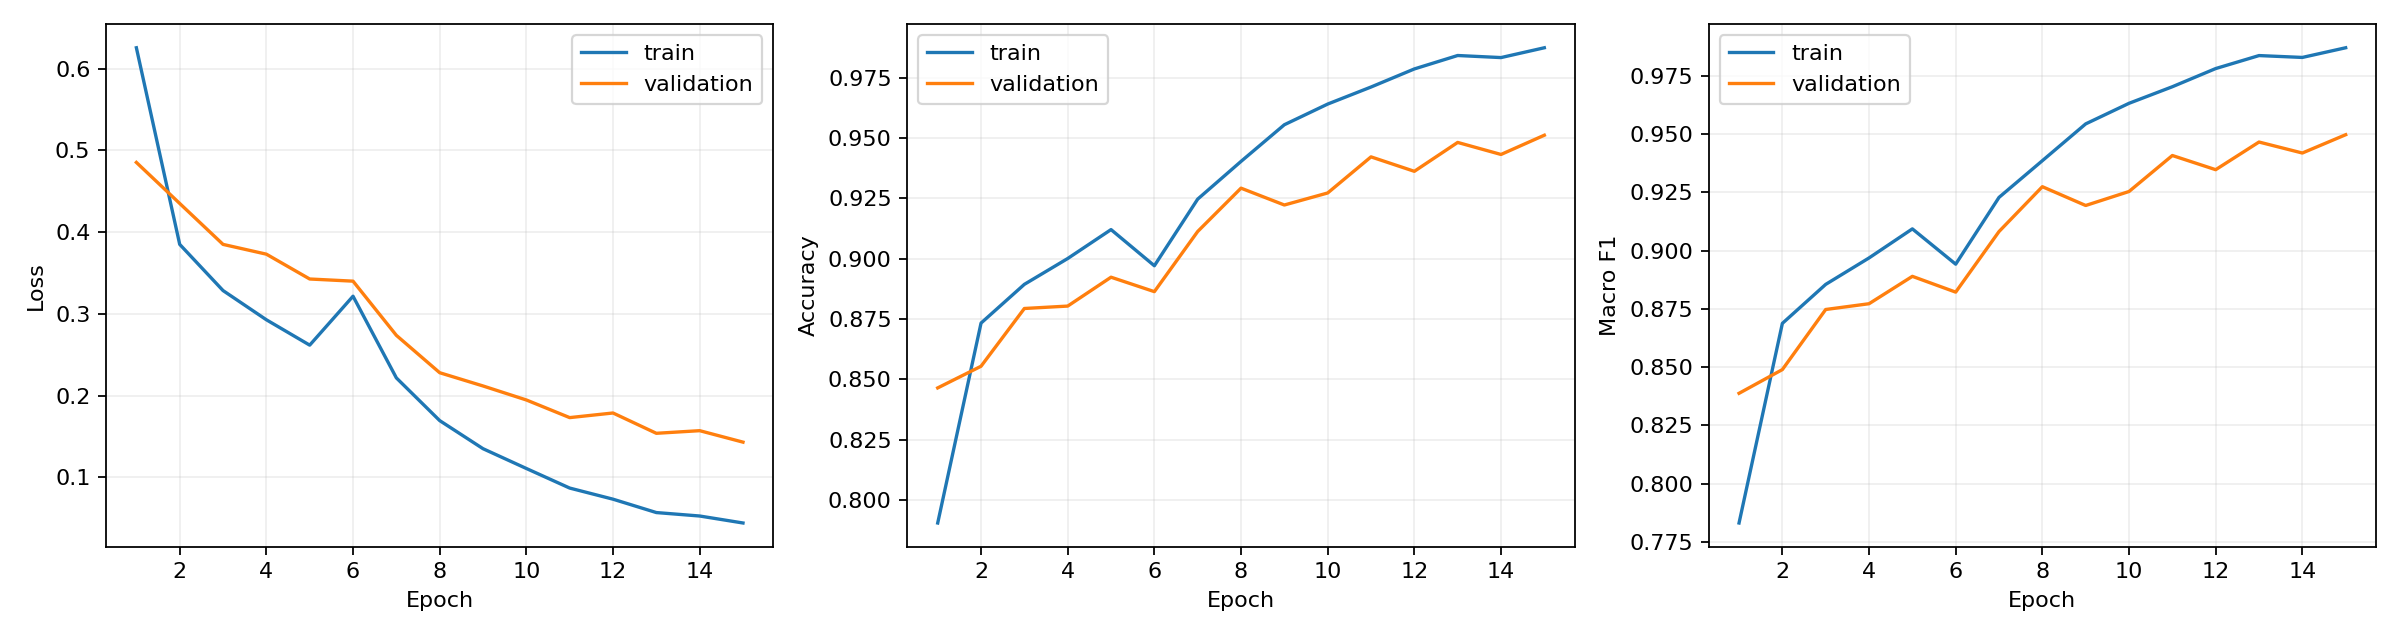

In [14]:
import os
import time
import json
from IPython.display import display, Image as NotebookImage

assert history and all(row["phase"] == "head" for row in history), (
    "Expected completed head-training history. Do not rerun fine-tuning."
)
assert (run_dir / "best.pt").is_file(), "Best head checkpoint is missing."

# Start from the best head-training epoch.
saved = torch.load(run_dir / "best.pt", map_location=device, weights_only=True)
assert saved["phase"] == "head", "Fine-tuning may have already started."
model.load_state_dict(saved["model_state_dict"])

best_f1 = float(saved["validation_macro_f1"])
best_loss = float(saved["validation_loss"])
best_epoch = int(saved["epoch"])

# Train only the final ResNet block and classification head.
configure_phase(model, "fine_tune")
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

phase_best_f1 = -1.0
phase_best_loss = float("inf")
non_improving = 0
start_epoch = history[-1]["epoch"]

for phase_epoch in range(1, 11):
    epoch = start_epoch + phase_epoch
    start = time.perf_counter()

    train_scores = run_epoch(
        model, train_loader, criterion, device,
        optimizer, scaler, "fine_tune"
    )
    with torch.inference_mode():
        val_scores = run_epoch(model, val_loader, criterion, device)

    scheduler.step(val_scores["loss"])

    history.append({
        "epoch": epoch,
        "phase": "fine_tune",
        **{f"train_{k}": v for k, v in train_scores.items()},
        **{f"val_{k}": v for k, v in val_scores.items()},
        "minutes": round((time.perf_counter() - start) / 60, 3),
        "head_lr": optimizer.param_groups[1]["lr"],
        "backbone_lr": optimizer.param_groups[0]["lr"],
    })
    save_history(run_dir / "history.csv", history)
    save_curves(run_dir / "learning_curves.png", history)

    improved = (
        val_scores["macro_f1"] > best_f1 + 1e-6
        or (
            abs(val_scores["macro_f1"] - best_f1) <= 1e-6
            and val_scores["loss"] < best_loss
        )
    )
    if improved:
        best_f1 = val_scores["macro_f1"]
        best_loss = val_scores["loss"]
        best_epoch = epoch
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": CLASS_TO_IDX,
            "weights": str(WEIGHTS),
            "epoch": epoch,
            "phase": "fine_tune",
            "validation_macro_f1": best_f1,
            "validation_loss": best_loss,
        }
        torch.save(checkpoint, run_dir / "best.tmp.pt")
        os.replace(run_dir / "best.tmp.pt", run_dir / "best.pt")

    phase_improved = (
        val_scores["macro_f1"] > phase_best_f1 + 1e-6
        or (
            abs(val_scores["macro_f1"] - phase_best_f1) <= 1e-6
            and val_scores["loss"] < phase_best_loss
        )
    )
    if phase_improved:
        phase_best_f1 = val_scores["macro_f1"]
        phase_best_loss = val_scores["loss"]
        non_improving = 0
    else:
        non_improving += 1

    print(
        f"Epoch {epoch} (fine-tune {phase_epoch}/10) | "
        f"train loss {train_scores['loss']:.4f}, "
        f"accuracy {train_scores['accuracy']:.4f} | "
        f"validation loss {val_scores['loss']:.4f}, "
        f"accuracy {val_scores['accuracy']:.4f}, "
        f"macro-F1 {val_scores['macro_f1']:.4f}"
        + ("  ← overall best" if improved else ""),
        flush=True,
    )

    if non_improving >= 4:
        print("Fine-tuning stopped early after 4 non-improving epochs.")
        break

summary = {
    "best_epoch": best_epoch,
    "best_validation_macro_f1": best_f1,
    "best_validation_loss": best_loss,
    "epochs_completed": history[-1]["epoch"],
    "checkpoint": str(run_dir / "best.pt"),
}
(run_dir / "training_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

print("Fine-tuning complete:", summary)
print("The test set has not been opened.")
display(NotebookImage(filename=str(run_dir / "learning_curves.png")))


Test accuracy: 0.9540
Test macro-F1: 0.9525

Results by class:
glioma       precision=0.950  recall=0.936  F1=0.943  images=266
meningioma   precision=0.926  recall=0.897  F1=0.911  images=223
notumor      precision=0.965  recall=0.992  F1=0.978  images=248
pituitary    precision=0.970  recall=0.985  F1=0.977  images=264


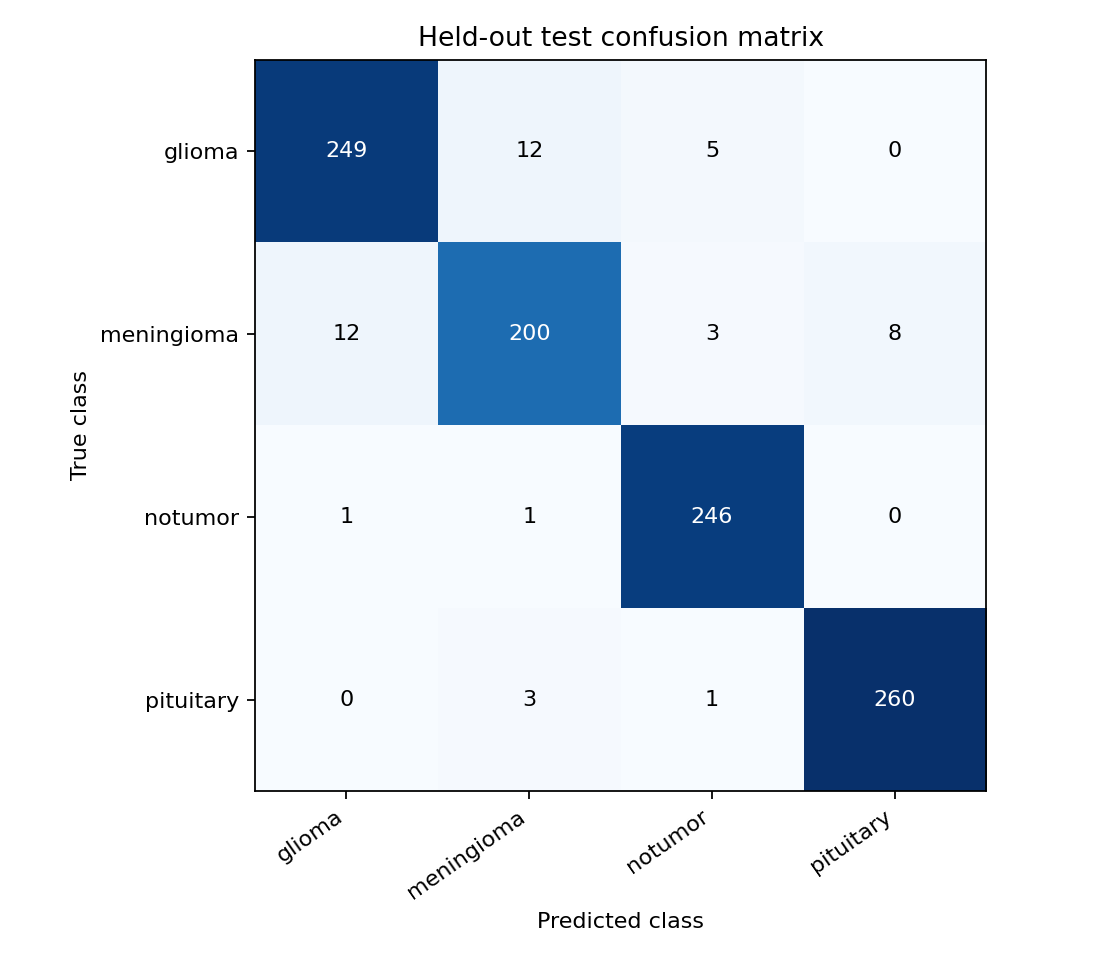

In [15]:
import sys
import json
import subprocess
from IPython.display import display, Image as NotebookImage

assert (run_dir / "training_summary.json").is_file(), "Training is not complete."
assert (run_dir / "best.pt").is_file(), "Best checkpoint is missing."
assert not (run_dir / "test_metrics.json").exists(), (
    "Test evaluation has already been completed. Do not run it again."
)

subprocess.run(
    [
        sys.executable,
        str(repo / "resnet50" / "evaluate.py"),
        "--data-root", str(data_root),
        "--run-dir", str(run_dir),
        "--batch-size", "16",
        "--num-workers", "2",
    ],
    check=True,
)

metrics = json.loads((run_dir / "test_metrics.json").read_text())

print(f"\nTest accuracy: {metrics['accuracy']:.4f}")
print(f"Test macro-F1: {metrics['macro_f1']:.4f}")
print("\nResults by class:")
for class_name in metrics["class_names"]:
    row = metrics["classification_report"][class_name]
    print(
        f"{class_name:12s} "
        f"precision={row['precision']:.3f}  "
        f"recall={row['recall']:.3f}  "
        f"F1={row['f1-score']:.3f}  "
        f"images={int(row['support'])}"
    )

display(NotebookImage(filename=str(run_dir / "test_confusion_matrix.png")))